In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

session_names = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", "JAL005_8thSept", "JAL005_21stSept",
                 "JAL5_8thSept", "JAL5_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}


Mouse: JAL006, Experiment: flip, Run number: 7 (JAL6): HDir 11 / 271
[WARN] Skipping Mouse: JAL006, Experiment: flip, Run number: 3: Access is denied. (os error 5): ...essed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hdir_Rayleigh.arrow
[WARN] Skipping Mouse: JAL006, Experiment: flip, Run number: 4: Access is denied. (os error 5): ...essed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hdir_Rayleigh.arrow
Mouse: JAL006, Experiment: flip, Run number: 5 (JAL6): HDir 3 / 116
Mouse: JAL006, Experiment: flip, Run number: 6 (JAL6): HDir 3 / 124
Mouse: JAL003, Experiment: flip_rotated_1, Run number: 0 (JAL3): HDir 0 / 100
Mouse: JAL003, Experiment: flip1stSept_003, Run number: 0 (JAL3): HDir 0 / 92
Mouse: JAL003, Experiment: flip4thSept_003, Run number: 0 (JAL3): HDir 0 / 57
Mouse: JAL003, Experiment: flip7thSept_003, Run number: 0 (JAL3): HDir 0 / 68
Mouse: JAL005, Experiment: flip_puff1_8th_sept_jal005, Run number: 1 (JAL5): HDir 5 / 318
Mouse: JAL005, Ex

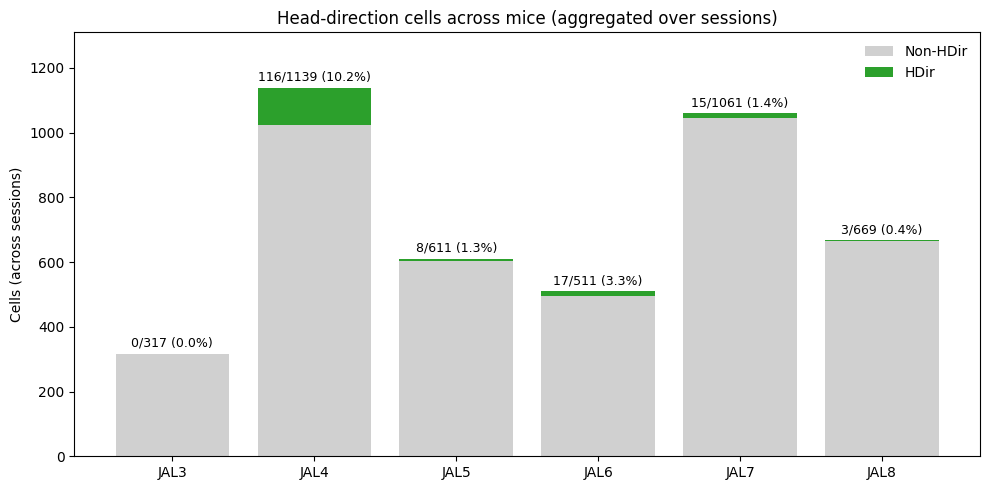

In [ ]:
# Head-direction cells per mouse across sessions (robust mouse inference + skip summary)

import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import extract_rayleigh_path, load_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values

# Thresholds (match your classifier script)
RAYLEIGH_THRESHOLD = 0.5
SIMILAR_ANGLE_THRESHOLD = 0.8
CLUSTER_TYPE = "good"  # good/curated clusters

def angle_similarity(theta1, theta2):
    # Circular difference in radians; similarity = cos(delta)
    delta = np.angle(np.exp(1j * (theta1 - theta2)))
    return float(np.cos(delta))

def rayleigh_threshold(mag_a, mag_b):
    return (mag_a >= RAYLEIGH_THRESHOLD) and (mag_b >= RAYLEIGH_THRESHOLD)

def check_both_compartments_significant(sig_pair):
    try:
        return bool(sig_pair[0]) and bool(sig_pair[1])
    except Exception:
        return False

def canonicalize_mouse(label: str) -> str:
    # Convert JAL006 -> JAL6, JAL005 -> JAL5, keep JAL7 etc.
    m = re.search(r"(JAL)0*([0-9]+)", label)
    if m:
        return f"{m.group(1)}{int(m.group(2))}"
    return label

def infer_mouse(session, session_to_mouse):
    # 1) by exact session name mapping
    session_name = getattr(session, "name", "")
    if session_name in session_to_mouse:
        return session_to_mouse[session_name]
    # 2) via attributes
    for attr in ("mouse", "mouse_id", "mouse_name"):
        val = getattr(session, attr, None)
        if isinstance(val, str) and val:
            return canonicalize_mouse(val)
    # 3) parse string repr "Mouse: JAL006, ..."
    m = re.search(r"Mouse:\s*(JAL0*\d+|JAL\d+)", str(session))
    if m:
        return canonicalize_mouse(m.group(1))
    return "UNKNOWN"

# ---- NEW: cross-backend column accessor (Polars/Pandas/iterable/dict) ----
def _to_list_like(col):
    if hasattr(col, "to_list"):   # Polars Series
        return col.to_list()
    if hasattr(col, "tolist"):    # NumPy/Pandas Series
        return col.tolist()
    try:
        return list(col)
    except Exception:
        return []

def column_as_list(df, name, default=None):
    """
    Return column values as a Python list across Polars/Pandas/dict.
    """
    if default is None:
        default = []
    if df is None:
        return default
    # dict-like
    if isinstance(df, dict):
        return _to_list_like(df.get(name, default))
    # DataFrame-like
    cols = getattr(df, "columns", None)
    if cols is not None and name in cols:
        try:
            col = df[name]
            return _to_list_like(col)
        except Exception:
            return default
    return default
# -------------------------------------------------------------------------

# Reverse lookup: session_name -> mouse (from your mice_groups)
session_to_mouse = {s: m for m, sessions in mice_groups.items() for s in sessions}

mouse_counts = defaultdict(lambda: {"total": 0, "hdir": 0})
skipped = []

for sess in experiments_objects:
    session = get_experiment(sess)
    mouse = infer_mouse(session, session_to_mouse)
    session_name = getattr(session, "name", str(session))

    # Load Rayleigh data for all_time head direction per session
    try:
        path = extract_rayleigh_path(session, CLUSTER_TYPE, condition="shelter_only", file_name="hdir_Rayleigh.arrow")
        data = load_rayleigh_data(path)
    except Exception as e:
        msg = str(e)
        print(f"[WARN] Skipping {session_name}: {msg}")
        skipped.append((mouse, session_name, msg))
        continue

    # ---- CHANGED: use column_as_list instead of data.get(...) ----
    cluster_ids = column_as_list(data, "clusterID", default=[])
    n_total = len(cluster_ids)
    # ---------------------------------------------------------------

    if n_total == 0:
        print(f"[WARN] No clusters in {session_name}")
        skipped.append((mouse, session_name, "no clusters"))
        continue

    angles = extract_compartment_values(data, "Rayleigh_theta")  # [theta_shelter, theta_barrier]
    mags   = extract_compartment_values(data, "Rayleigh")        # [mag_shelter, mag_barrier]
    sigs   = extract_compartment_values(data, "Rayleigh_sig")    # [sig_shelter, sig_barrier]

    n_hdir = 0
    for i in range(n_total):
        try:
            sim = angle_similarity(angles[i][0], angles[i][1])
            above = rayleigh_threshold(mags[i][0], mags[i][1])
            sig   = check_both_compartments_significant(sigs[i])
            if (sim > SIMILAR_ANGLE_THRESHOLD) and above and sig:
                n_hdir += 1
        except Exception:
            continue

    mouse_counts[mouse]["total"] += n_total
    mouse_counts[mouse]["hdir"]  += n_hdir
    print(f"{session_name} ({mouse}): HDir {n_hdir} / {n_total}")

# Summary of skipped sessions
if skipped:
    by_reason = defaultdict(int)
    for _, _, msg in skipped:
        by_reason[msg.split(':')[0]] += 1
    print(f"\n[INFO] Skipped {len(skipped)} sessions. Top reasons:")
    for reason, cnt in sorted(by_reason.items(), key=lambda x: -x[1])[:5]:
        print(f"  {reason}: {cnt}")

# Prepare plot data
mice = sorted([m for m in mouse_counts.keys() if m != "UNKNOWN"]) or ["UNKNOWN"]
totals = np.array([mouse_counts[m]["total"] for m in mice], dtype=int)
hdirs  = np.array([mouse_counts[m]["hdir"]  for m in mice], dtype=int)
non_hdir = totals - hdirs
pct = np.where(totals > 0, 100.0 * hdirs / totals, 0.0)

# Plot stacked bars: HDir vs Non-HDir per mouse
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mice))
ax.bar(x, non_hdir, color="#d0d0d0", label="Non-HDir")
ax.bar(x, hdirs, bottom=non_hdir, color="#2ca02c", label="HDir")

# Annotate counts and percentage on top
for i, (t, h, p) in enumerate(zip(totals, hdirs, pct)):
    ax.text(i, t + max(1, totals.max())*0.01, f"{h}/{t} ({p:.1f}%)", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(mice, rotation=0)
ax.set_ylabel("Cells (across sessions)")
ax.set_title("Head-direction cells across mice (aggregated over sessions)")
ax.legend(frameon=False)
ax.set_ylim(0, max(1, totals.max()) * 1.15)

# save as eps
save_path = r"Z:\Laurence\thesis\efizz_chapter"
plt.savefig(f"{save_path}/hdir_cells_across_mice.eps", format='eps', dpi=300)

plt.tight_layout()
plt.show()


save hdir cells for hsa remove classifciaiton - Saves per-session HD cluster IDs to .../processed/cells/hdir_cells.pkl — exactly what the HSA script expects to auto-load and exclude.

In [8]:
# classify_hdir_cells.py
import os
import re
import dill as pickle
import numpy as np
from collections import defaultdict
from loguru import logger

from behave_analysis.process.session import get_experiment
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.utils.rayleigh.load_rayleigh import extract_rayleigh_path, load_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values

# ---------------- USER CONFIG ----------------
RAYLEIGH_THRESHOLD = 0.5          # your HD threshold
SIMILAR_ANGLE_THRESHOLD = 0.8     # in [0,1] after mapping below
CLUSTER_TYPE = "good"             # "good" or "curated", etc.
OUT_FILENAME = "hdir_cells.pkl"   # what the HSA code expects

# ------------- YOUR SESSIONS -----------------
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [
    JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
    JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
    JAL005_8thSept, JAL005_21stSept,
    JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr,
    JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may, JAL8_tiny_3may, JAL8_21may,
    JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
]

mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr', 'JAL7_30apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may', 'JAL8_tiny_3may', 'JAL8_21may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept'],
}

# ---------- backend-safe accessors ----------
def _to_list_like(col):
    if hasattr(col, "to_list"):
        return col.to_list()   # Polars
    if hasattr(col, "tolist"):
        return col.tolist()    # NumPy/Pandas
    try:
        return list(col)
    except Exception:
        return []

def column_as_list(df, name, default=None):
    if default is None:
        default = []
    if df is None:
        return default
    if isinstance(df, dict):
        return _to_list_like(df.get(name, default))
    cols = getattr(df, "columns", None)
    if cols is not None and name in cols:
        try:
            return _to_list_like(df[name])
        except Exception:
            return default
    return default

# --------------- small utilities ---------------
def canonicalize_mouse(label: str) -> str:
    m = re.search(r"(JAL)0*([0-9]+)", label or "")
    if m:
        return f"{m.group(1)}{int(m.group(2))}"
    return label or "UNKNOWN"

def infer_mouse(session, session_to_mouse):
    name = getattr(session, "name", "")
    if name in session_to_mouse:
        return session_to_mouse[name]
    for attr in ("mouse", "mouse_id", "mouse_name"):
        val = getattr(session, attr, None)
        if isinstance(val, str) and val:
            return canonicalize_mouse(val)
    m = re.search(r"Mouse:\s*(JAL0*\d+|JAL\d+)", str(session))
    if m:
        return canonicalize_mouse(m.group(1))
    return "UNKNOWN"

def angle_similarity(theta1: float, theta2: float) -> float:
    """Return similarity in [0,1] (consistent with HSA code)."""
    delta = np.angle(np.exp(1j * (theta1 - theta2)))   # [-pi, pi]
    cos_sim = float(np.cos(delta))                     # [-1, 1]
    return 0.5 * (cos_sim + 1.0)                       # [0, 1]

def rayleigh_threshold(m1: float, m2: float) -> bool:
    return (m1 >= RAYLEIGH_THRESHOLD) and (m2 >= RAYLEIGH_THRESHOLD)

def check_both_compartments_significant(sig_pair) -> bool:
    try:
        return bool(sig_pair[0]) and bool(sig_pair[1])
    except Exception:
        return False

def save_cell_ids(session, cell_ids, fname=OUT_FILENAME):
    out_dir = make_directory(os.path.join(session.base_path, session.processed_path, "cells"))
    fpath = os.path.join(out_dir, fname)
    with open(fpath, "wb") as f:
        pickle.dump(list(cell_ids), f)
    logger.success(f"Saved {len(cell_ids)} HD cells -> {fpath}")

# --------------- core: classify one session ---------------
def classify_hdir(session, cluster_type: str = CLUSTER_TYPE, save: bool = True):
    """
    Classify Head-Direction (HD) cells for a single session using shelter_only Rayleigh.
    Criteria:
      - angle similarity > SIMILAR_ANGLE_THRESHOLD
      - Rayleigh magnitude >= RAYLEIGH_THRESHOLD in both compartments
      - both compartments significant
    Saves clusterIDs to processed/cells/hdir_cells.pkl (if save=True).
    Returns list(clusterIDs).
    """
    path = extract_rayleigh_path(session, cluster_type, condition="shelter_only",
                                 file_name="hdir_Rayleigh.arrow")
    data = load_rayleigh_data(path)

    cluster_ids = column_as_list(data, "clusterID", default=[])
    if not cluster_ids:
        logger.warning("No clusters found in Rayleigh data.")
        if save:
            save_cell_ids(session, [])
        return []

    angles = extract_compartment_values(data, "Rayleigh_theta")
    mags   = extract_compartment_values(data, "Rayleigh")
    sigs   = extract_compartment_values(data, "Rayleigh_sig")

    hd_cells = []
    for i, cid in enumerate(cluster_ids):
        try:
            sim = angle_similarity(angles[i][0], angles[i][1])
            above = rayleigh_threshold(mags[i][0], mags[i][1])
            sig   = check_both_compartments_significant(sigs[i])
            if (sim > SIMILAR_ANGLE_THRESHOLD) and above and sig:
                hd_cells.append(cid)
        except Exception as e:
            logger.warning(f"Skipping cluster {cid}: {e}")
            continue

    if save:
        save_cell_ids(session, hd_cells)
    return hd_cells

# --------------- batch runner ---------------
def run_all_sessions(experiments, mice_groups):
    session_to_mouse = {s: m for m, sessions in mice_groups.items() for s in sessions}
    counts = defaultdict(lambda: {"total": 0, "hd": 0})
    skipped = []

    for sess in experiments:
        session = get_experiment(sess)
        name = getattr(session, "name", str(session))
        mouse = infer_mouse(session, session_to_mouse)
        try:
            # classify & save
            hd = classify_hdir(session, CLUSTER_TYPE, save=True)

            # report denominators
            path = extract_rayleigh_path(session, CLUSTER_TYPE, condition="shelter_only",
                                         file_name="hdir_Rayleigh.arrow")
            data = load_rayleigh_data(path)
            total = len(column_as_list(data, "clusterID", default=[]))

            counts[mouse]["hd"] += len(hd)
            counts[mouse]["total"] += total
            logger.info(f"{name} ({mouse}): HD {len(hd)} / {total}")
        except Exception as e:
            logger.warning(f"[SKIP] {name}: {e}")
            skipped.append((mouse, name, str(e)))

    if skipped:
        logger.warning(f"Skipped {len(skipped)} sessions.")
    return counts

# ------------------- MAIN -------------------
if __name__ == "__main__":
    run_all_sessions(experiments_objects, mice_groups)


2025-09-25 10:16:11.275 | SUCCESS  | __main__:save_cell_ids:112 - Saved 15 HD cells -> Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_7_take2_2024_04_01T11_24_46\processed_data\cells\hdir_cells.pkl
2025-09-25 10:16:11.294 | INFO     | __main__:run_all_sessions:178 - Mouse: JAL006, Experiment: flip, Run number: 7 (JAL6): HD 15 / 271
2025-09-25 10:16:11.301 | WARNING  | __main__:run_all_sessions:180 - [SKIP] Mouse: JAL006, Experiment: flip, Run number: 3: Access is denied. (os error 5): ...essed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hdir_Rayleigh.arrow
2025-09-25 10:16:11.303 | WARNING  | __main__:run_all_sessions:180 - [SKIP] Mouse: JAL006, Experiment: flip, Run number: 4: Access is denied. (os error 5): ...essed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hdir_Rayleigh.arrow
2025-09-25 10:16:12.080 | SUCCESS  | __main__:save_cell_ids:112 - Saved 4 HD cells -> Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelte